# FINAL PROJECT EDM

## Dokumentasi Dataset: Grab App Reviews - Indonesia (Google Play Store)

Dataset ini berisi ulasan pengguna terhadap aplikasi Grab pada platform Google Play Store dalam bahasa Indonesia. Informasi yang terkandung di dalam dataset mencakup identitas pengguna, isi ulasan, penilaian kuantitatif, hingga metrik interaksi antar-pengguna.

kaggle:https://www.kaggle.com/datasets/pandaa12/grab-app-reviews-indonesia-google-play-store

### Kamus Data (Column Descriptors)

Berikut adalah deskripsi lengkap mengenai kolom-kolom yang terdapat di dalam dataset:

| Nama Kolom | Tipe Data Riil | Deskripsi | Keterangan / Rentang Nilai |
| :--- | :--- | :--- | :--- |
| **Nama User** | String | Nama atau identitas akun pengguna yang menuliskan ulasan. | Sering kali berisi nilai bawaan (*default value*) seperti "Pengguna Google". |
| **Ulasan** | Text / String | Teks isi ulasan yang disampaikan oleh pengguna dalam bahasa Indonesia. | Berisi opini, kritik, saran, atau keluhan terkait aplikasi dan layanan. |
| **Rating** | Integer | Penilaian kuantitatif dalam bentuk angka bintang yang diberikan oleh pengguna. | Skala nilai berkisar antara **1** (Sangat Buruk) hingga **5** (Sangat Bagus). |
| **Tanggal** | Datetime | Catatan waktu (*timestamp*) kapan ulasan tersebut diterbitkan oleh pengguna. | Format standar waktu (UTC atau lokal setempat). |
| **Likes** | Integer | Jumlah tanda suka (*thumbs-up/helpful votes*) yang diterima ulasan tersebut dari pengguna lain. | Mengindikasikan seberapa relevan atau validnya ulasan tersebut bagi komunitas. |
| **Versi App** | String | Versi aplikasi Grab yang terpasang di perangkat pengguna saat mengunggah ulasan. | Digunakan untuk mengidentifikasi bug atau performa pada versi sistem tertentu. |

---

## EDA

In [126]:
import pandas as pd

In [166]:
df = pd.read_csv("ulasan_com.grabtaxi.passenger.csv")
df.head()

,Nama User,Ulasan,Rating,Tanggal,Likes,Versi App
0,Pengguna Google,astaga batalin makanan yg udh telat 5 jam lama...,1,2025-12-31 17:14:37,0,5.389.0
1,Pengguna Google,"ribet membatalkan pesanan aj ribet banget, dan...",1,2025-12-31 17:05:27,0,NaN
2,Pengguna Google,membantu sangat,5,2025-12-31 16:39:44,0,5.389.0
3,Pengguna Google,mantap,5,2025-12-31 16:35:13,0,5.389.0
4,Pengguna Google,pesanan 2 jam lebih,2,2025-12-31 16:25:44,0,5.389.0


In [235]:
df['Nama User'].value_counts()

Nama User
Pengguna Google    99005
Ahmad                  2
Semend Smith           1
Lia Putri              1
Akmal Kurniawan        1
                   ...  
Faisol Idris           1
Azmi Azmi              1
andi assegaf           1
Anton Nov              1
Teguh Diyanto          1
Name: count, Length: 995, dtype: int64

In [128]:
print(f"Total Baris: {df.shape[0]}")
print(f"Total Kolom: {df.shape[1]}")
print("\nKolom yang tersedia:\n", df.columns.tolist())

Total Baris: 100000
Total Kolom: 6

Kolom yang tersedia:
 ['Nama User', 'Ulasan', 'Rating', 'Tanggal', 'Likes', 'Versi App']


In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Nama User  100000 non-null  object
 1   Ulasan     100000 non-null  object
 2   Rating     100000 non-null  int64 
 3   Tanggal    100000 non-null  object
 4   Likes      100000 non-null  int64 
 5   Versi App  86230 non-null   object
dtypes: int64(2), object(4)
memory usage: 4.6+ MB


In [130]:
df.describe()

,Rating,Likes
count,100000.00000,100000.000000
mean,4.22347,1.192360
std,1.46335,32.153234
min,1.00000,0.000000
25%,4.00000,0.000000
50%,5.00000,0.000000
75%,5.00000,0.000000
max,5.00000,3396.000000


## DATA PREPROCESSING

In [168]:
df_clean = df.copy()

### Memeriksa missing value

In [132]:
df_clean.isna().sum()

Nama User        0
Ulasan           0
Rating           0
Tanggal          0
Likes            0
Versi App    13770
dtype: int64

### Memeriksa data duplikat

In [133]:
df_clean.duplicated().sum()

0

### Menghapus kolom yang tidak diperlukan dan memiliki banyak missing value

In [169]:
df_clean.drop(columns=['Nama User', 'Tanggal', 'Versi App'], inplace=True)
df_clean.head()

,Ulasan,Rating,Likes
0,astaga batalin makanan yg udh telat 5 jam lama...,1,0
1,"ribet membatalkan pesanan aj ribet banget, dan...",1,0
2,membantu sangat,5,0
3,mantap,5,0
4,pesanan 2 jam lebih,2,0


### Standarissi data

In [170]:
import re

# Ubah semua teks menjadi huruf kecil
df_clean['Ulasan'] = df_clean['Ulasan'].str.lower()

# Hapus karakter berulang
df_clean['Ulasan'] = df_clean['Ulasan'].apply(lambda x: re.sub(r'(.)\1+', r'\1', str(x)))

# Hapus karakter khusus yang tidak umum
df_clean['Ulasan'] = df_clean['Ulasan'].str.replace(r'[^a-z0-9\s\.,!?;:\-\(\)]','',regex=True)

# Hapus spasi berlebih
df_clean['Ulasan'] = df_clean['Ulasan'].str.replace(r'\s+', ' ', regex=True).str.strip()

df_clean[['Ulasan']].head()

,Ulasan
0,astaga batalin makanan yg udh telat 5 jam lama...
1,"ribet membatalkan pesanan aj ribet banget, dan..."
2,membantu sangat
3,mantap
4,pesanan 2 jam lebih


### Penghapusan Stopwords

In [171]:
# Kata yang paling sering muncul di dalam twit

text = " ".join(tweet for tweet in df_clean['Ulasan'].values)

# Inisialisasi stopword
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())
stopwords.update([
    'yg','ga','gak','nggak','ngga','nya','aja','nih','sih',
    'dong','deh','kok','lah','pun','tuh','ya','yah','oke',
    'ok','wkwk','wk','haha','hehe','hihi','amp','rt', 'jadi', 
    'cuma', 'jg', 'gw', 'mau', 'udah', 'cuma', 'bgt', 'banget',
    'biar', 'semua', 'terus', 'apa', 'buat', 'sama', 'aku', 'kita', 'lagi', 'https',
    'gini', 'kalau', 'lebih', 'kalo', 'malah','.', 'yang', 'di', 'dan', '?', ')', '(', ':', ';', '!', ','
])

### Mengambil 2.000 data

In [200]:
df_sample = df_clean.head(2000)

## EDA

In [138]:
from nltk.tokenize import word_tokenize
from collections import Counter

# Gabungkan semua tweet
text = " ".join(df_sample['Ulasan'].astype(str))

# Tokenisasi
words = word_tokenize(text)

# Hapus stopword HANYA untuk visualisasi
filtered_words = [word for word in words if word not in stopwords]

# Gabungkan lagi untuk WordCloud
filtered_text = " ".join(filtered_words)

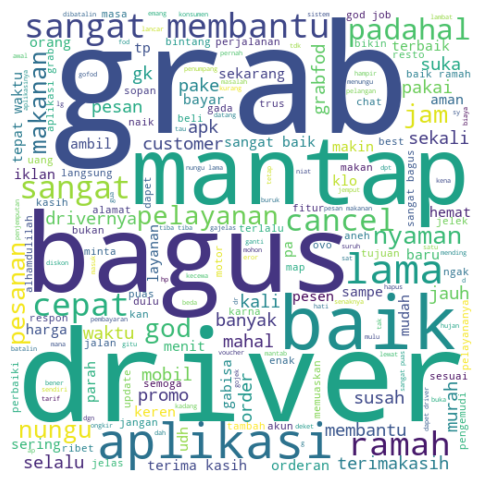

In [139]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=500,
    height=500,
    background_color='white'
).generate(filtered_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [140]:
word_freq = Counter(filtered_words)

top20 = word_freq.most_common(20)
df_top20 = pd.DataFrame(top20, columns=['Kata','Frekuensi'])

display(df_top20)

,Kata,Frekuensi
0,grab,312
1,driver,283
2,sangat,239
3,bagus,199
4,baik,188
5,aplikasi,146
6,mantap,140
7,ramah,134
8,membantu,122
9,lama,102


## SENTIMENT ANALYSIS & LABELLING

In [173]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification

pretrained = "mdhugol/indonesia-bert-sentiment-classification"

model = AutoModelForSequenceClassification.from_pretrained(pretrained)
tokenizer = AutoTokenizer.from_pretrained(pretrained)

sentiment_analysis = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

label_index = {'LABEL_0': 'positive', 'LABEL_1': 'neutral', 'LABEL_2': 'negative'}

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 16243.84it/s]


In [201]:
sentimen = []
confidence = []

for text in df_sample['Ulasan']:
    result = sentiment_analysis(text)[0]
    sentimen.append(label_index[result['label']])
    confidence.append(result['score'] * 100)

df_sample['Sentimen'] = sentimen
df_sample['Confidence Sentimen'] = confidence

df_sample.head()

,Ulasan,Rating,Likes,Sentimen,Confidence Sentimen
0,astaga batalin makanan yg udh telat 5 jam lama...,1,0,negative,99.517280
1,"ribet membatalkan pesanan aj ribet banget, dan...",1,0,negative,99.143022
2,membantu sangat,5,0,positive,98.669004
3,mantap,5,0,positive,99.719977
4,pesanan 2 jam lebih,2,0,neutral,82.514817


### Distribusi Sentimen

In [143]:
df_sample['Sentimen'].value_counts()

Sentimen
positive    1361
negative     535
neutral      104
Name: count, dtype: int64

### Rata Rata Confidence Sentimen

In [144]:
df_sample['Confidence Sentimen'].mean()

95.64679168313742

In [145]:
df_sample.groupby('Sentimen')['Confidence Sentimen'].mean().round(2)

Sentimen
negative    95.10
neutral     80.45
positive    97.02
Name: Confidence Sentimen, dtype: float64

## TOPIC ANALYSIS & LABELLING

In [175]:
from bertopic import BERTopic

In [202]:
docs = df_sample['Ulasan'].tolist()

topic_model = BERTopic(
    language="multilingual",
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)

2026-07-02 15:28:25,422 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 63/63 [00:11<00:00,  5.69it/s]
2026-07-02 15:28:48,964 - BERTopic - Embedding - Completed ✓
2026-07-02 15:28:48,965 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-02 15:28:55,075 - BERTopic - Dimensionality - Completed ✓
2026-07-02 15:28:55,083 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-02 15:28:55,544 - BERTopic - Cluster - Completed ✓
2026-07-02 15:28:55,589 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-02 15:28:55,727 - BERTopic - Representation - Completed ✓


In [203]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,413,-1_di_driver_grab_bisa,"[di, driver, grab, bisa, saya, yang, ada, yg, ...",[jujur selama pakai greb bikin emosi drever ya...
1,0,115,0_mantap_recomended_bermanfat_sgt,"[mantap, recomended, bermanfat, sgt, kepake, m...","[mantap, mantap, mantap]"
2,1,86,1_bagus_sagat_telat_baik,"[bagus, sagat, telat, baik, dan, gak, nya, , , ]","[bagus, bagus, bagus]"
3,2,74,2_baik_sempurna_perfect_terpercaya,"[baik, sempurna, perfect, terpercaya, akurat, ...","[baik, baik, baik]"
4,3,72,3_driver_mau_nya_ga,"[driver, mau, nya, ga, yg, banyak, yang, jauh,...","[cuma mau menyampaikan keluhan ke grab, kenapa..."
5,4,68,4_ok_okeh_okei_important,"[ok, okeh, okei, important, thnk, overal, godj...","[ok, ok, ok]"
6,5,64,5_aplikasi_grab_aplikasinya_ini,"[aplikasi, grab, aplikasinya, ini, download, s...","[aplikasi sangat membantu, aplikasi yang bagus..."
7,6,59,6_pelayanan_pelayananya_layanan_bagus,"[pelayanan, pelayananya, layanan, bagus, baik,...","[pelayanan bagus, pelayanan bagus, pelayanan b..."
8,7,57,7_god_very_jop_aplication,"[god, very, jop, aplication, like, godjob, so,...","[god, god, god]"
9,8,54,8_mantab_mntap_bgus_jos,"[mantab, mntap, bgus, jos, jelek, pisan, lemot...","[mantab, mantab, mantab]"


In [204]:
topics, probs = topic_model.fit_transform(docs)
topic_model.reduce_topics(docs, nr_topics=5)
topic_model.get_topic_info()

2026-07-02 15:29:06,435 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 63/63 [00:09<00:00,  6.55it/s]
2026-07-02 15:29:16,096 - BERTopic - Embedding - Completed ✓
2026-07-02 15:29:16,097 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-02 15:29:21,781 - BERTopic - Dimensionality - Completed ✓
2026-07-02 15:29:21,781 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-02 15:29:22,060 - BERTopic - Cluster - Completed ✓
2026-07-02 15:29:22,068 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-02 15:29:22,128 - BERTopic - Representation - Completed ✓
2026-07-02 15:29:22,287 - BERTopic - Topic reduction - Reducing number of topics
2026-07-02 15:29:22,319 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-02 15:29:22,351 - BERTopic - Representation - Completed ✓
2026-07-02 15:29:22,351 - BERTopic - Topic reduction - Reduced nu

,Topic,Count,Name,Representation,Representative_Docs
0,-1,350,-1_grab_di_saya_bisa,"[grab, di, saya, bisa, aplikasi, ada, yang, da...",[kecewa sih sama para grab yang suka milih cus...
1,0,1147,0_bagus_sangat_baik_mantap,"[bagus, sangat, baik, mantap, ok, membantu, da...","[sangat bagus, sangat bagus, sangat bagus dan ..."
2,1,221,1_driver_nya_di_dan,"[driver, nya, di, dan, grab, saya, drivernya, ...",[eh ini grab sistem nya gimana sih? masa drive...
3,2,204,2_di_bisa_makanan_tidak,"[di, bisa, makanan, tidak, saya, nya, lama, to...",[kalau buat harga tolong lebih di perhatikan. ...
4,3,78,3_god_job_very_aplication,"[god, job, very, aplication, task, jop, like, ...","[god, god, god]"


### Labelling

In [205]:
df_sample["Topic"] = topic_model.topics_

topic_labels = {
    -1: "Outlier",
    0: "Kualitas Pelayanan Grab",
    1: "Kinerja Aplikasi dan Sistem Grab",
    2: "Kualitas Pelayanan Driver",
    3: "Akurasi Lokasi dan Navigasi"
}

df_sample["Topic_Label"] = df_sample["Topic"].map(topic_labels)

df_sample.head(20)

,Ulasan,Rating,Likes,Sentimen,Confidence Sentimen,Topic,Topic_Label
0,astaga batalin makanan yg udh telat 5 jam lama...,1,0,negative,99.517280,2,Kualitas Pelayanan Driver
1,"ribet membatalkan pesanan aj ribet banget, dan...",1,0,negative,99.143022,2,Kualitas Pelayanan Driver
2,membantu sangat,5,0,positive,98.669004,-1,Outlier
3,mantap,5,0,positive,99.719977,0,Kualitas Pelayanan Grab
4,pesanan 2 jam lebih,2,0,neutral,82.514817,2,Kualitas Pelayanan Driver
5,ap sampah,1,0,negative,99.691558,0,Kualitas Pelayanan Grab
6,rusak ni aplikasi grab. pesanan gua udh 2 jam ...,1,0,negative,98.870683,2,Kualitas Pelayanan Driver
7,buruk,1,0,negative,99.797434,2,Kualitas Pelayanan Driver
8,apesnya.pesanan saya dgn no pesanan gf-62 tida...,1,0,negative,99.662316,2,Kualitas Pelayanan Driver
9,terimakasih,5,0,positive,91.485095,0,Kualitas Pelayanan Grab


## EDA After Sentiment & Topic Analysis

In [230]:
df_sample['Topic_Label'].value_counts()

Topic_Label
Kualitas Pelayanan Grab             1147
Outlier                              350
Kinerja Aplikasi dan Sistem Grab     221
Kualitas Pelayanan Driver            204
Akurasi Lokasi dan Navigasi           78
Name: count, dtype: int64

### Distribusi Sentimen pada Setiap Topik

In [206]:
topic_sentiment = pd.crosstab(df_sample['Topic_Label'], df_sample['Sentimen'], normalize='index') * 100

print("\nPersentase Sentimen dalam Setiap Topik (%):")
print(topic_sentiment.round(2))


Persentase Sentimen dalam Setiap Topik (%):
Sentimen                          negative  neutral  positive
Topic_Label                                                  
Akurasi Lokasi dan Navigasi           0.00     1.28     98.72
Kinerja Aplikasi dan Sistem Grab     59.73     8.60     31.67
Kualitas Pelayanan Driver            76.47    10.78     12.75
Kualitas Pelayanan Grab               6.80     2.53     90.67
Outlier                              48.29     9.43     42.29


### Rata-Rata Rating pada setiap sentimen

In [207]:
df_sample.groupby("Sentimen")["Rating"].mean()

Sentimen
negative    1.725234
neutral     2.894231
positive    4.851580
Name: Rating, dtype: float64

### Rata - Rata Likes pasa Setiap Sentimen

In [208]:
df_sample.groupby("Sentimen")["Likes"].mean()

Sentimen
negative    1.024299
neutral     0.375000
positive    0.256429
Name: Likes, dtype: float64

### Rata-Rata Jumlah kata per sentimen

In [209]:
# Hitung jumlah kata tiap ulasan
df_sample["Jumlah_Kata"] = df_sample["Ulasan"].str.split().str.len()

avg_word = (
    df_sample.groupby("Sentimen")["Jumlah_Kata"]
    .mean()
    .round(2)
    .reset_index(name="Rata-rata Jumlah Kata")
)

avg_word

,Sentimen,Rata-rata Jumlah Kata
0,negative,20.46
1,neutral,12.08
2,positive,3.38


## MODEL KLASIFIKASI

### Modeling klasifikasi untuk prediksi sentimen

In [210]:
sentiment_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

df_sample['Sentimen'] = df_sample['Sentimen'].map(sentiment_map)
df_sample.head()

,Ulasan,Rating,Likes,Sentimen,Confidence Sentimen,Topic,Topic_Label,Jumlah_Kata
0,astaga batalin makanan yg udh telat 5 jam lama...,1,0,0,99.517280,2,Kualitas Pelayanan Driver,10
1,"ribet membatalkan pesanan aj ribet banget, dan...",1,0,0,99.143022,2,Kualitas Pelayanan Driver,31
2,membantu sangat,5,0,2,98.669004,-1,Outlier,2
3,mantap,5,0,2,99.719977,0,Kualitas Pelayanan Grab,1
4,pesanan 2 jam lebih,2,0,1,82.514817,2,Kualitas Pelayanan Driver,4


Memeriksa distribusi sentimen

In [211]:
df_sample['Sentimen'].value_counts()

Sentimen
2    1361
0     535
1     104
Name: count, dtype: int64

Memisahkan variabel dependen, independen, dan split data

In [158]:
from sklearn.model_selection import train_test_split

x_sen = df_sample['Ulasan']
y_sen = df_sample['Sentimen']

x_sen_train, x_sen_test, y_sen_train, y_sen_test = train_test_split(x_sen, y_sen, test_size=0.2, random_state=42)

Tokenisasi

In [160]:
from transformers import AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained(
    "indobenchmark/indobert-base-p1",
    use_fast=True
)

def tokenize_function(examples):
    return tokenizer(examples.tolist(), padding='max_length', max_length=256, truncation=True)

x_train_tokenized = tokenize_function(x_sen_train)
x_test_tokenized = tokenize_function(x_sen_test)

NUM_LABELS = y_sen_train.nunique()
model = AutoModelForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1",
    num_labels=NUM_LABELS
)

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5106.65it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Train

In [161]:
from transformers import TrainingArguments

training_args = TrainingArguments("test_trainer")

In [162]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    'input_ids': x_train_tokenized['input_ids'],
    'attention_mask': x_train_tokenized['attention_mask'],
    'labels': y_sen_train.tolist()
})

eval_dataset = Dataset.from_dict({
    'input_ids': x_test_tokenized['input_ids'],
    'attention_mask': x_test_tokenized['attention_mask'],
    'labels': y_sen_test.tolist()
})

In [163]:
from transformers import Trainer
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average="weighted")
    recall = recall_score(labels, predictions, average="weighted")
    f1 = f1_score(labels, predictions, average="weighted")

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
)

training_history = trainer.train()
evaluation_history = trainer.evaluate()

Step,Training Loss
500,0.214205


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.36it/s]


Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
0.214205,0.290622,600,0.937500,0.937069,0.937500,0.934486


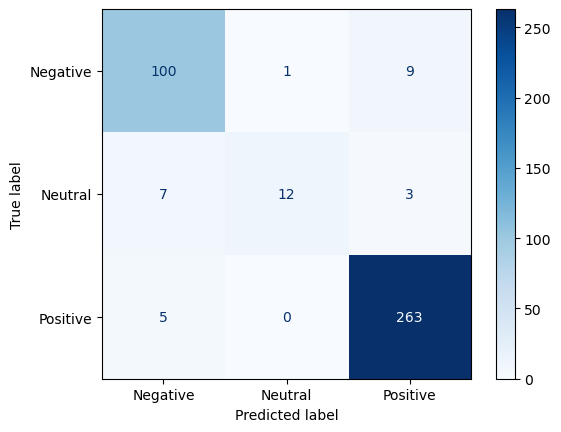

In [164]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

predictions = trainer.predict(eval_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)

cm = confusion_matrix(y_sen_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Neutral", "Positive"]
)

disp.plot(cmap="Blues")
plt.show()

## Model Klasifikasi untuk prediksi topik

Mapping topik

In [213]:
topic_map = {
    -1: 0,
    0: 1,
    1: 2,
    2: 3,
    3: 4   
}

df_sample['Topic'] = df_sample['Topic'].map(topic_map)
df_sample.head()

,Ulasan,Rating,Likes,Sentimen,Confidence Sentimen,Topic,Topic_Label,Jumlah_Kata
0,astaga batalin makanan yg udh telat 5 jam lama...,1,0,0,99.517280,3,Kualitas Pelayanan Driver,10
1,"ribet membatalkan pesanan aj ribet banget, dan...",1,0,0,99.143022,3,Kualitas Pelayanan Driver,31
2,membantu sangat,5,0,2,98.669004,0,Outlier,2
3,mantap,5,0,2,99.719977,1,Kualitas Pelayanan Grab,1
4,pesanan 2 jam lebih,2,0,1,82.514817,3,Kualitas Pelayanan Driver,4


Memisahkan variabel dependen, independen, dan membagi dataset

In [216]:
x_top = df_sample['Ulasan']
y_top = df_sample['Topic']

x_top_train, x_top_test, y_top_train, y_top_test = train_test_split(x_top, y_top, test_size=0.2, random_state=42)

Tokenisasi

In [223]:
def tokenize_function(examples):
    return tokenizer(examples.tolist(), padding='max_length', max_length=256, truncation=True)

x_train_tokenized2 = tokenize_function(x_sen_train)
x_test_tokenized2 = tokenize_function(x_sen_test)

NUM_LABELS = y_top_train.nunique()
model2 = AutoModelForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1",
    num_labels=NUM_LABELS
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6559.78it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Train

In [224]:
training_args2 = TrainingArguments("test_trainer")

In [225]:
train_dataset = Dataset.from_dict({
    'input_ids': x_train_tokenized2['input_ids'],
    'attention_mask': x_train_tokenized2['attention_mask'],
    'labels': y_top_train.tolist()
})

eval_dataset = Dataset.from_dict({
    'input_ids': x_test_tokenized2['input_ids'],
    'attention_mask': x_test_tokenized2['attention_mask'],
    'labels': y_top_test.tolist()
})

In [226]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average="weighted")
    recall = recall_score(labels, predictions, average="weighted")
    f1 = f1_score(labels, predictions, average="weighted")

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

trainer2 = Trainer(
    model=model2,
    args=training_args2,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
)

training_history = trainer2.train()
evaluation_history = trainer2.evaluate()

Step,Training Loss
500,0.458556


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.25s/it]


Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
0.458556,0.761234,600,0.800000,0.785028,0.800000,0.788362


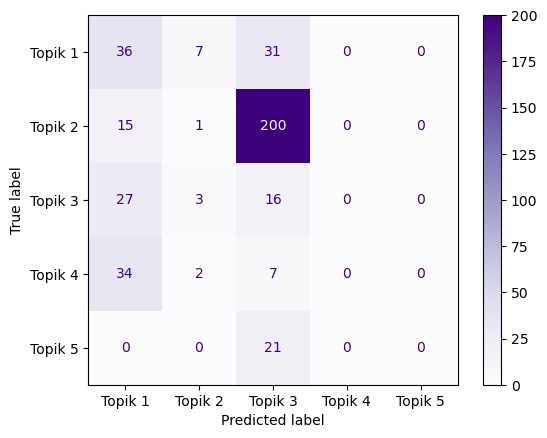

In [227]:
cm = confusion_matrix(y_top_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Topik 1", "Topik 2", "Topik 3", "Topik 4", "Topik 5"]
)

disp.plot(cmap="Purples")
plt.show()

## SAVE MODEL

In [234]:
model.save_pretrained("model_sentimen_saved")
model2.save_pretrained("model_topik_saved")
tokenizer.save_pretrained("tokenizer_saved")

Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.37s/it]


('tokenizer_saved\\tokenizer_config.json', 'tokenizer_saved\\tokenizer.json')